In [1]:
from sklearn.svm import LinearSVC, SVC
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from utils.evaluation import evaluate_pipeline
from utils import column_type_split, feature_importance_df
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("../data/train_clear.csv")

SVM подвержен проклятию размерности, поэтому сразу используем только важные фичи XGBoost и масштабирование

In [3]:
important_features = [
    "Sym_Ascites",
    "Sym_Fatigue",
    "Sym_Dark_Urine",
    "Sym_Jaundice",
    "ALT",
    "Bilirubin",
    "AST",
    "Comorb_Diabetes",
    "Sym_Abdominal_Pain",
    "Sym_Itching",
]

In [4]:
target = "Liver_Disease_Type"
X = df[important_features]
y = df[target]

In [5]:
pipeline_linear_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC())
])

Модель LinearSVC
F1-macro: 0.645 ± 0.007
F1-weighted: 0.742 ± 0.004


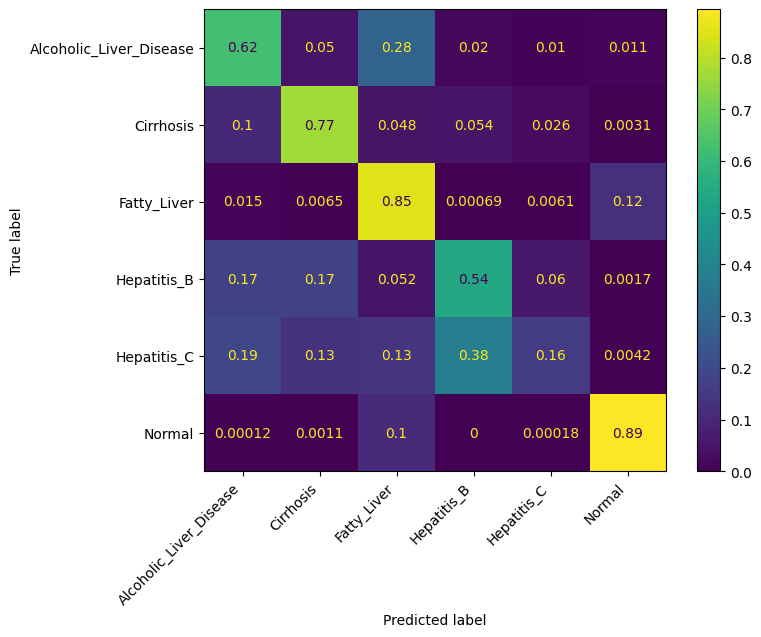

In [6]:
evaluate_pipeline(pipeline_linear_svc, X, y)

In [7]:
pipeline_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", SVC())
])

0 fold: fitting
0 fold: scoring
1 fold: fitting
1 fold: scoring
2 fold: fitting
2 fold: scoring
3 fold: fitting
3 fold: scoring
4 fold: fitting
4 fold: scoring
Модель SVC
F1-macro: 0.727 ± 0.005
F1-weighted: 0.803 ± 0.004


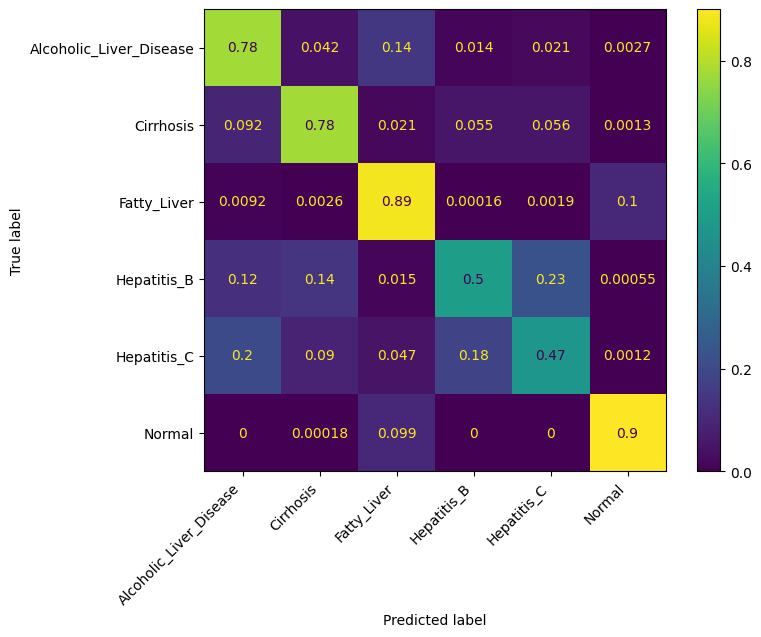

In [8]:
evaluate_pipeline(pipeline_svc, X, y, verbose=True)

SVC дал точность выше LinearSVC из-за нелинейного разделения объектов, но и обучался в 120 раз дольше (4 минуты против 2 секунд)